In [3]:
import os
import glob
import torch
import matplotlib.pyplot as plt
import cv2

In [1]:
pip install ultralytics

   ---------------------------------------- 0.0/949.3 kB ? eta -:--:--
   ---------------------------------------- 949.3/949.3 kB 5.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\chchc\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 21.5M/21.5M [00:03<00:00, 5.73MB/s]



0: 384x640 1 car, 102.7ms
Speed: 3.2ms preprocess, 102.7ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs\detect\predict


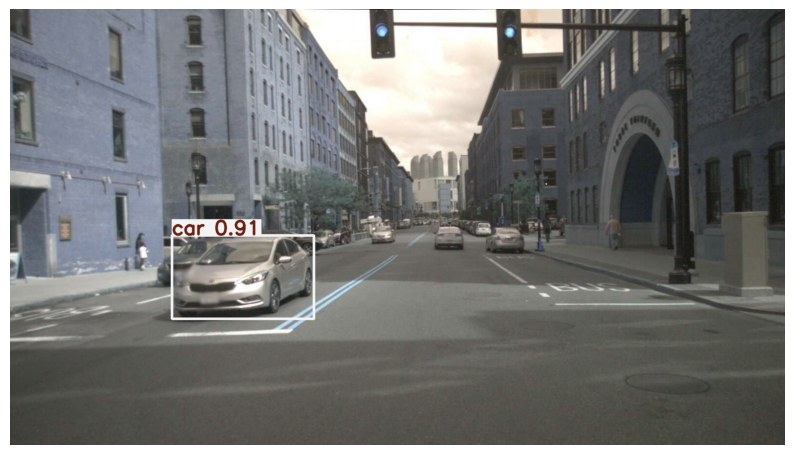

Bounding Boxes (x1, y1, x2, y2, confidence, class_id):
(334.99, 467.07, 627.48, 639.67), Confidence: 0.91, Class ID: 2


In [15]:
image_folder = "C:/Users/chchc/Documents/25_3_1/IoT/yolo/scenes"
 
image_paths = sorted(glob.glob(os.path.join(image_folder, "*.png")) + 
                     glob.glob(os.path.join(image_folder, "*.jpg")))

if not image_paths:
    print("No image")
else:
    results = model.predict(image_paths, save=True, conf=0.9)

    first_result = results[0]

    img = cv2.imread(image_paths[0])  
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR -> RGB

    ####### Result plotting #######
    plt.figure(figsize=(10, 6))
    plt.imshow(first_result.plot())  
    plt.axis("off")
    plt.show()

    print("Bounding Boxes (x1, y1, x2, y2, confidence, class_id):")
    for box in first_result.boxes.data:
        x1, y1, x2, y2, conf, cls = box.tolist()
        print(f"({x1:.2f}, {y1:.2f}, {x2:.2f}, {y2:.2f}), Confidence: {conf:.2f}, Class ID: {int(cls)}")